In [1]:
# Figure 2: occupancy vs. output (Claim 2). For each of the 7 census-relevant genes
# (the 2 reference genes plus all 5 from Table 1), does ATFS-1 ChIP occupancy at the
# promoter track with how strongly the gene is induced? Reads regulon ranks from
# results/, re-derives peak positions and fold-enrichment from the raw ChIP data and
# the WS285 annotation the same way analysis_c.ipynb and table_1.ipynb do, and
# re-validates against the same known-true values before drawing anything.
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")
import sys
sys.path.insert(0, "scripts")

import gzip
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from figure_style import BLUE, ORANGE, GREEN, GREY, INK, FULL_W, figure_label, save

GENES = ["hsp-6", "hsp-60", "dnj-10", "ymel-1", "prx-19", "cbp-3", "tspo-1"]
GENE_IDS = {
    "hsp-6": "WBGene00002010", "hsp-60": "WBGene00002025",
    "dnj-10": "WBGene00001028", "ymel-1": "WBGene00010842",
    "prx-19": "WBGene00004201", "cbp-3": "WBGene00009595",
    "tspo-1": "WBGene00077771",
}

regulon = pd.read_csv("results/regulon_61.csv").set_index("public_name")
reference = pd.read_csv("results/reference_genes.csv").set_index("public_name")

output = {}
for g in ["dnj-10", "ymel-1", "prx-19", "cbp-3", "tspo-1"]:
    r = regulon.loc[g]
    output[g] = {"score": r["score"], "score_var": r["score_var"],
                 "rank_score": int(r["rank_score"]), "rank_var": int(r["rank_var"]), "n": 61}
for g in ["hsp-6", "hsp-60"]:
    r = reference.loc[g]
    output[g] = {"score": r["score"], "score_var": r["score_var"],
                 "rank_score": int(r["rank_score_inserted"]), "rank_var": int(r["rank_var_inserted"]), "n": 62}

EXPECTED_RANKS = {
    "dnj-10": (23, 45), "ymel-1": (58, 61), "prx-19": (20, 54),
    "cbp-3": (57, 44), "tspo-1": (21, 42),
    "hsp-6": (29, 43), "hsp-60": (62, 62),
}
for g, (exp_var, exp_score) in EXPECTED_RANKS.items():
    got = (output[g]["rank_var"], output[g]["rank_score"])
    if got != (exp_var, exp_score):
        raise RuntimeError(f"{g}: rank mismatch, got {got}, expected {(exp_var, exp_score)} - results/ is stale.")
print("Output-side ranks validated for all 7 genes.")

Output-side ranks validated for all 7 genes.


In [2]:
# Gene models: coordinates, strand, TSS, and operon status, read directly off the
# WS285 GFF3 (same parse as analysis_c.ipynb / table_1.ipynb). ymel-1 and tspo-1 are
# downstream operon members and were the two genes where operon-head-vs-own-TSS
# logic mattered during binding reconciliation - both TSS candidates are kept here
# so the figure can show why.
GFF = "data/raw/c_elegans.PRJNA13758.WS285.annotations.gff3.gz"

operons = {}
with gzip.open(GFF, "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        f = line.rstrip("\n").split("\t")
        if len(f) < 9 or f[1] != "operon" or f[2] != "operon":
            continue
        attrs = dict(kv.split("=", 1) for kv in f[8].split(";") if "=" in kv)
        name = attrs.get("Name")
        members = attrs.get("genes", "").split(",") if attrs.get("genes") else []
        if name and members:
            operons[name] = members
gene_to_head = {m: members[0] for members in operons.values() for m in members[1:]}

WANT_IDS = set(GENE_IDS.values()) | {gene_to_head[g] for g in GENE_IDS.values() if g in gene_to_head}
models = {}
with gzip.open(GFF, "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        f = line.rstrip("\n").split("\t")
        if len(f) < 9 or f[1] != "WormBase" or f[2] != "gene":
            continue
        attrs = dict(kv.split("=", 1) for kv in f[8].split(";") if "=" in kv)
        gid = attrs.get("ID", "").replace("Gene:", "")
        if gid in WANT_IDS:
            models[gid] = {"chr": f[0], "start": int(f[3]), "end": int(f[4]), "strand": f[6],
                            "seqname": attrs.get("sequence_name", "")}
for m in models.values():
    m["tss"] = m["start"] if m["strand"] == "+" else m["end"]

genes = {}
for name, gid in GENE_IDS.items():
    m = dict(models[gid])
    m["name"] = name
    if gid in gene_to_head:
        head = models[gene_to_head[gid]]
        m["head_tss"] = head["tss"]
        m["head_chr"] = head["chr"]
    else:
        m["head_tss"] = None
    genes[name] = m

EXPECTED_OPERON = {"ymel-1": True, "tspo-1": True, "hsp-6": False, "hsp-60": False,
                    "dnj-10": False, "prx-19": False, "cbp-3": False}
for name, is_downstream in EXPECTED_OPERON.items():
    got = genes[name]["head_tss"] is not None
    if got != is_downstream:
        raise RuntimeError(f"{name}: operon status mismatch, expected downstream={is_downstream}, got {got}.")
print("Operon status validated: ymel-1 and tspo-1 are downstream members, the other 5 are not.")
for name, g in genes.items():
    print(f"  {name:8s} {g['seqname']:10s} chr{g['chr']:>4s} strand{g['strand']} TSS={g['tss']:>9,} "
          f"{'(operon head TSS=' + format(g['head_tss'], ',') + ')' if g['head_tss'] else ''}")

Operon status validated: ymel-1 and tspo-1 are downstream members, the other 5 are not.
  hsp-6    C37H5.8    chr   V strand- TSS=4,826,760 
  hsp-60   Y22D7AL.5  chr III strand+ TSS=1,619,742 
  dnj-10   F22B7.5    chr III strand+ TSS=8,631,165 
  ymel-1   M03C11.5   chr III strand+ TSS=10,416,139 (operon head TSS=10,405,070)
  prx-19   F54F2.8    chr III strand- TSS=8,809,295 
  cbp-3    F40F12.7   chr III strand+ TSS=9,913,993 
  tspo-1   C41G7.9    chr   I strand- TSS=9,516,776 (operon head TSS=9,518,736)


In [3]:
# Peaks: liftover output carries only coordinates, so fold-enrichment and FDR are
# rejoined from the raw GSE63803 file by row index - the bed file was built by
# enumerating that same dataframe in order (binding.ipynb), and every one of its
# 1,005 rows mapped in the liftover (0 unmapped, checked at build time), so the
# index alignment is exact, not assumed.
peaks = pd.read_csv("data/liftover/peaks_ce11.bed", sep="\t", header=None,
                     names=["chr", "start", "end", "name"])
peaks["chr"] = peaks["chr"].str.replace("^chr", "", regex=True)
raw_peaks = pd.read_csv("data/raw/GSE63803_peaks.txt.gz", sep="\t", skiprows=23).dropna(subset=["start", "end"]).reset_index(drop=True)
if len(peaks) != len(raw_peaks):
    raise RuntimeError(f"Peak count mismatch: {len(peaks)} lifted vs {len(raw_peaks)} raw - index alignment broken.")
peaks["fold_enrichment"] = raw_peaks["fold_enrichment"].values
peaks["FDR"] = raw_peaks["FDR(%)"].values
peaks["macs_gene"] = raw_peaks["Gene Name"].values

WINDOW_KB = 12

def nearby_peaks(chrom, tss):
    lo, hi = tss - WINDOW_KB * 1000, tss + WINDOW_KB * 1000
    hit = peaks[(peaks["chr"] == chrom) & (peaks["start"] <= hi) & (peaks["end"] >= lo)]
    return hit

gene_peaks = {}
for name, g in genes.items():
    hits = nearby_peaks(g["chr"], g["tss"])
    gene_peaks[name] = hits
    print(f"{name:8s}: {len(hits)} peak(s) within {WINDOW_KB}kb of TSS")

# Validate against the two peak-level facts already on record in gate_decisions.md:
# ymel-1's own-TSS peak (fold-enrichment 13.08, FDR 4%) and tspo-1's peak sitting
# 190bp from its own TSS but 2,150bp from its operon head's TSS (the exact "150bp
# outside the 2kb window" figure the binding-reconciliation note describes).
ymel1_peak = gene_peaks["ymel-1"]
ymel1_at_tss = ymel1_peak[(ymel1_peak["start"] <= genes["ymel-1"]["tss"]) & (ymel1_peak["end"] >= genes["ymel-1"]["tss"])]
if len(ymel1_at_tss) != 1:
    raise RuntimeError("ymel-1: expected exactly one peak at its own TSS.")
fe, fdr = ymel1_at_tss.iloc[0]["fold_enrichment"], ymel1_at_tss.iloc[0]["FDR"]
if round(fe, 2) != 13.08 or round(fdr, 2) != 4.0:
    raise RuntimeError(f"ymel-1 TSS peak: expected FE=13.08 FDR=4.0, got FE={fe} FDR={fdr}.")

tspo1_peak = gene_peaks["tspo-1"].iloc[0]
own_dist = min(abs(tspo1_peak["start"] - genes["tspo-1"]["tss"]), abs(tspo1_peak["end"] - genes["tspo-1"]["tss"]))
head_dist = min(abs(tspo1_peak["start"] - genes["tspo-1"]["head_tss"]), abs(tspo1_peak["end"] - genes["tspo-1"]["head_tss"]))
if not (own_dist < 2000 <= head_dist < 2200):
    raise RuntimeError(f"tspo-1 peak distances don't match the recorded reconciliation: own={own_dist}, head={head_dist}.")

print("\nPeak-level facts validated: ymel-1 TSS peak FE=13.08/FDR=4%, "
      f"tspo-1 own-TSS distance {own_dist}bp (bound) vs operon-head distance {head_dist}bp (would be unbound).")

hsp-6   : 2 peak(s) within 12kb of TSS
hsp-60  : 1 peak(s) within 12kb of TSS
dnj-10  : 0 peak(s) within 12kb of TSS
ymel-1  : 2 peak(s) within 12kb of TSS
prx-19  : 1 peak(s) within 12kb of TSS
cbp-3   : 0 peak(s) within 12kb of TSS
tspo-1  : 1 peak(s) within 12kb of TSS

Peak-level facts validated: ymel-1 TSS peak FE=13.08/FDR=4%, tspo-1 own-TSS distance 190bp (bound) vs operon-head distance 2150bp (would be unbound).


In [4]:
# This-study bound call for all 7 genes (2kb, own-or-head TSS - same rule as
# analysis_c.ipynb / table_1.ipynb), re-derived here for the same self-validation
# reason as the other table/figure notebooks.
def is_bound(name):
    g = genes[name]
    for _, p in gene_peaks[name].iterrows():
        if (p["start"] - 2000) <= g["tss"] <= (p["end"] + 2000):
            return True
        if g["head_tss"] is not None and (p["start"] - 2000) <= g["head_tss"] <= (p["end"] + 2000):
            return True
    return False

this_study_bound = {name: is_bound(name) for name in GENES}
EXPECTED_BOUND = {"hsp-6": True, "hsp-60": True, "dnj-10": False, "ymel-1": True,
                   "prx-19": True, "cbp-3": False, "tspo-1": True}
if this_study_bound != EXPECTED_BOUND:
    raise RuntimeError(f"Bound-call mismatch: got {this_study_bound}, expected {EXPECTED_BOUND}.")
print("This-study bound calls validated for all 7 genes:")
for name in GENES:
    print(f"  {name:8s}: {'bound' if this_study_bound[name] else 'not bound'}")

This-study bound calls validated for all 7 genes:
  hsp-6   : bound
  hsp-60  : bound
  dnj-10  : not bound
  ymel-1  : bound
  prx-19  : bound
  cbp-3   : not bound
  tspo-1  : bound


Saved figures/figure2_occupancy_vs_output.{pdf,svg,png}


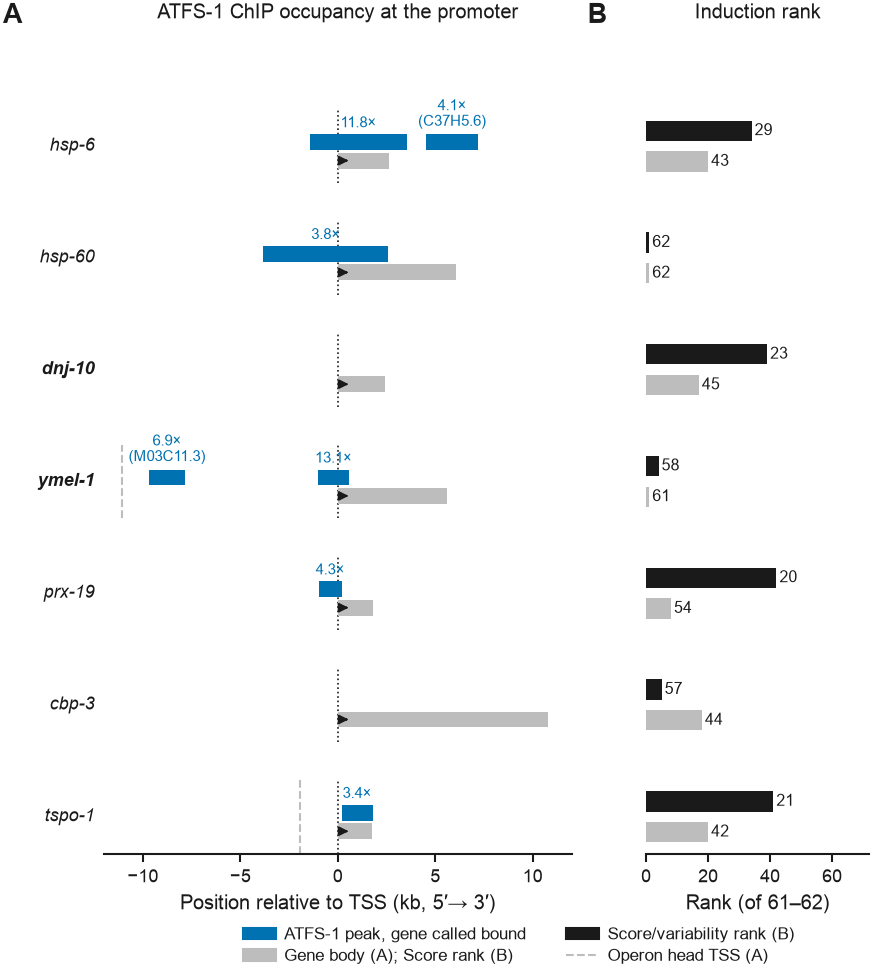

In [5]:
# Draw. Left: promoter occupancy, every gene oriented 5'->3' left-to-right with the
# TSS at 0 (minus-strand genes are mirrored, so "into the gene body" is always the
# positive-x direction - the usual ChIP meta-track convention, and what makes peak
# position comparable across genes that sit on different strands). Right: induction
# rank on both metrics per the standing dual-metric rule, drawn so a longer bar
# always means stronger induction, matching "peak nearer 0 = stronger occupancy" on
# the left.
def to_plot_x(name, genomic_pos):
    g = genes[name]
    return (genomic_pos - g["tss"]) / 1000 if g["strand"] == "+" else (g["tss"] - genomic_pos) / 1000

# MACS assigned each peak to its own nearest gene at call time, which is not
# necessarily the gene whose row it lands in: the 12kb display window is wider than
# the 2kb binding-call window, so a neighbour's peak can appear inside a row's frame.
# Any peak whose MACS gene name is not one of the row gene's own names (public,
# sequence, or historical alias) is labelled with that name, so it reads as genomic
# context rather than as an extra hit on this gene.
OWN_ALIASES = {
    "hsp-6": {"hsp-6"}, "hsp-60": {"hsp-60"},
    "dnj-10": {"dnj-10", "f22b7.5"}, "ymel-1": {"ymel-1", "yme-1", "m03c11.5"},
    "prx-19": {"prx-19", "f54f2.8"}, "cbp-3": {"cbp-3", "f40f12.7"},
    "tspo-1": {"tspo-1", "c41g7.9"},
}
STRICT_CENSUS = {"dnj-10", "ymel-1"}
# Track whether the not-bound colour is ever actually drawn. As it happens every gene
# in this panel that has a peak at all is also called bound, so the orange never
# appears - and a legend advertising a colour the reader cannot find is worse than a
# shorter legend. The branch stays (it is the correct rule) but the key is built from
# what was drawn, not from what could have been.
used_not_bound = False

fig = plt.figure(figsize=(FULL_W, FULL_W * 0.92))
n = len(GENES)
row_h = 0.80 / n
left_w, gap, right_w = 0.44, 0.07, 0.21
left_x0 = 0.11
right_x0 = left_x0 + left_w + gap

for i, name in enumerate(GENES):
    top = 0.88 - i * row_h
    ax_l = fig.add_axes([left_x0, top - row_h * 0.78, left_w, row_h * 0.66])
    ax_r = fig.add_axes([right_x0, top - row_h * 0.78, right_w, row_h * 0.66])
    g = genes[name]

    gx0, gx1 = sorted([to_plot_x(name, g["start"]), to_plot_x(name, g["end"])])
    ax_l.add_patch(mpatches.Rectangle((gx0, -0.30), gx1 - gx0, 0.60,
                                      facecolor=GREY, edgecolor="none", zorder=2))
    arrow_x = gx0 + 0.15 if gx1 - gx0 > 0.3 else gx1
    ax_l.annotate("", xy=(arrow_x + 0.4, 0), xytext=(arrow_x, 0),
                  arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.0), zorder=3)

    for _, p in gene_peaks[name].iterrows():
        px0, px1 = sorted([to_plot_x(name, p["start"]), to_plot_x(name, p["end"])])
        color = BLUE if this_study_bound[name] else ORANGE
        if not this_study_bound[name]:
            used_not_bound = True
        ax_l.add_patch(mpatches.Rectangle((px0, 0.40), px1 - px0, 0.60,
                                          facecolor=color, edgecolor="none", zorder=4))
        label = f"{p['fold_enrichment']:.1f}×"
        if str(p["macs_gene"]).strip().lower() not in OWN_ALIASES[name]:
            label += f"\n({p['macs_gene']})"
        ax_l.text((px0 + px1) / 2, 1.15, label, ha="center", va="bottom",
                  fontsize=7, color=color, linespacing=1.25)

    ax_l.axvline(0, color=INK, lw=0.8, ls=":", zorder=1)
    if g["head_tss"] is not None:
        head_x = to_plot_x(name, g["head_tss"])
        # Identified in the legend rather than labelled in place. A per-row text label
        # has nowhere to go in these short axes: below the line it hits the row's own
        # axis, above it collides with the peak fold-enrichment labels, and rotating
        # it needs more vertical room than a row is tall.
        ax_l.axvline(head_x, color=GREY, lw=1.0, ls="--", zorder=1)

    ax_l.set_xlim(-12, 12)
    ax_l.set_ylim(-0.85, 1.95)
    ax_l.set_yticks([])
    ax_l.text(-0.02, 0.5, name, transform=ax_l.transAxes, fontsize=8.5, va="center",
              ha="right", color=INK, style="italic",
              fontweight="bold" if name in STRICT_CENSUS else "normal")
    for spine in ("top", "right", "left"):
        ax_l.spines[spine].set_visible(False)
    if i == n - 1:
        ax_l.set_xlabel("Position relative to TSS (kb, 5′→ 3′)", labelpad=4)
    else:
        # Only the bottom row carries the axis. Keeping a bare spine on every row
        # added six horizontal rules that read as table borders rather than as axes.
        ax_l.set_xticks([])
        ax_l.spines["bottom"].set_visible(False)

    # Panel B uses ink/grey rather than blue/grey: blue means "ATFS-1 peak" in panel
    # A, and reusing it here for a rank bar made one colour carry two unrelated
    # meanings in the same figure. Score/variability stays the darker of the two,
    # per the rule that the conservative metric reads as primary.
    o = output[name]
    ax_r.barh([1], [o["n"] - o["rank_var"] + 1], height=0.66, color=INK)
    ax_r.barh([0], [o["n"] - o["rank_score"] + 1], height=0.66, color=GREY)
    ax_r.text(o["n"] - o["rank_var"] + 2, 1, str(o["rank_var"]), va="center",
              ha="left", fontsize=7.5, color=INK)
    ax_r.text(o["n"] - o["rank_score"] + 2, 0, str(o["rank_score"]), va="center",
              ha="left", fontsize=7.5, color=INK)
    ax_r.set_xlim(0, 72)
    ax_r.set_ylim(-0.7, 1.7)
    ax_r.set_yticks([])
    for spine in ("top", "right", "left"):
        ax_r.spines[spine].set_visible(False)
    if i == n - 1:
        ax_r.set_xlabel("Rank (of 61–62)", labelpad=4)
    else:
        ax_r.set_xticks([])
        ax_r.spines["bottom"].set_visible(False)

figure_label(fig, "A", 0.015, 0.975)
figure_label(fig, "B", right_x0 - 0.055, 0.975)
fig.text(left_x0 + left_w / 2, 0.955, "ATFS-1 ChIP occupancy at the promoter",
         fontsize=9.5, ha="center", va="bottom", color=INK)
fig.text(right_x0 + right_w / 2, 0.955, "Induction rank",
         fontsize=9.5, ha="center", va="bottom", color=INK)

legend_handles = [mpatches.Patch(color=BLUE, label="ATFS-1 peak, gene called bound")]
if used_not_bound:
    legend_handles.append(
        mpatches.Patch(color=ORANGE, label="ATFS-1 peak, gene not called bound"))
legend_handles += [
    mpatches.Patch(color=GREY, label="Gene body (A); Score rank (B)"),
    mpatches.Patch(color=INK, label="Score/variability rank (B)"),
    Line2D([0], [0], color=GREY, lw=1.0, ls="--", label="Operon head TSS (A)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.02), fontsize=8, columnspacing=2.4)

save(fig, "figure2_occupancy_vs_output")
plt.show()